In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree,
)


# Configuration


In [53]:
DATASET_PATH = Path("datasets/45V-400mV_ml/ml_dataset.csv")

TARGET_COLUMN = "target_led_residual_ps"

# First model to inspect.
MAX_DEPTH = 4

# Depths tested in the complexity scan.
DEPTH_VALUES = list(range(1, 21))

TEST_SIZE = 0.25
RANDOM_STATE = 42

# Number of features shown in importance plots.
TOP_N_FEATURES = 20

# Number of permutations for test-set permutation importance.
N_PERMUTATION_REPEATS = 30

In [54]:
df = pd.read_csv(DATASET_PATH)

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Rows:    6,736
Columns: 32


,meta_event_index,meta_event_id,meta_source_file_id,target_led_residual_ps,energy_ch1_max_amplitude_mV,energy_ch1_noise_rms_mV,energy_ch1_rise_t05_to_t50_ps,energy_ch1_t05_minus_timing_ch3_led_ps,energy_ch1_t50_minus_timing_ch3_led_ps,energy_ch2_max_amplitude_mV,...,timing_ch3_poly_rmse_mV,timing_ch4_max_amplitude_mV,timing_ch4_noise_rms_mV,timing_ch4_poly_c0,timing_ch4_poly_c1,timing_ch4_poly_c2,timing_ch4_poly_c3,timing_ch4_poly_c4,timing_ch4_poly_r2,timing_ch4_poly_rmse_mV
0,3,3,3;3;3;3,-25289.103851,465.461143,1.465668,8987.128023,26629.324569,35616.452592,463.457399,...,9.555734,166.188344,1.422668,62.028215,202.054591,54.122539,-155.213474,-52.704776,0.879819,24.898412
1,4,4,4;4;4;4,132.285149,467.967733,1.463304,9071.905971,1276.969526,10348.875497,468.488346,...,24.877812,161.591816,1.061181,62.652498,203.876018,49.673971,-158.295746,-46.786566,0.880906,24.818054
2,12,12,12;12;12;12,-14103.365851,458.416554,1.542146,8065.412185,15545.974760,23611.386945,466.568920,...,19.235305,161.844335,1.227801,62.452779,204.360353,50.510792,-159.069144,-47.182134,0.877860,25.199579
3,14,14,14;14;14;14,140.134149,457.993031,1.493385,8821.104783,1359.794081,10180.898864,471.261134,...,25.138521,161.778077,1.009525,62.563829,204.492411,50.890163,-159.526935,-47.645226,0.877260,25.251350
4,19,19,19;19;19;19,124.639149,462.603425,1.528071,9287.116679,1313.177941,10600.294620,464.298695,...,24.938021,162.084824,1.232555,62.442362,204.629867,53.056775,-160.139901,-49.219215,0.877934,25.145325


In [55]:
print("Column names:")
for column in df.columns:
    print(column)

Column names:
meta_event_index
meta_event_id
meta_source_file_id
target_led_residual_ps
energy_ch1_max_amplitude_mV
energy_ch1_noise_rms_mV
energy_ch1_rise_t05_to_t50_ps
energy_ch1_t05_minus_timing_ch3_led_ps
energy_ch1_t50_minus_timing_ch3_led_ps
energy_ch2_max_amplitude_mV
energy_ch2_noise_rms_mV
energy_ch2_rise_t05_to_t50_ps
energy_ch2_t05_minus_timing_ch4_led_ps
energy_ch2_t50_minus_timing_ch4_led_ps
timing_ch3_max_amplitude_mV
timing_ch3_noise_rms_mV
timing_ch3_poly_c0
timing_ch3_poly_c1
timing_ch3_poly_c2
timing_ch3_poly_c3
timing_ch3_poly_c4
timing_ch3_poly_r2
timing_ch3_poly_rmse_mV
timing_ch4_max_amplitude_mV
timing_ch4_noise_rms_mV
timing_ch4_poly_c0
timing_ch4_poly_c1
timing_ch4_poly_c2
timing_ch4_poly_c3
timing_ch4_poly_c4
timing_ch4_poly_r2
timing_ch4_poly_rmse_mV


In [56]:
metadata_columns = [
    column for column in df.columns
    if column.startswith("meta_")
]

excluded_columns = metadata_columns + [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
    and pd.api.types.is_numeric_dtype(df[column])
]

print(f"Metadata columns: {metadata_columns}")
print(f"Target column:    {TARGET_COLUMN}")
print(f"Input features:   {len(feature_columns)}")

for feature in feature_columns:
    print(feature)

Metadata columns: ['meta_event_index', 'meta_event_id', 'meta_source_file_id']
Target column:    target_led_residual_ps
Input features:   28
energy_ch1_max_amplitude_mV
energy_ch1_noise_rms_mV
energy_ch1_rise_t05_to_t50_ps
energy_ch1_t05_minus_timing_ch3_led_ps
energy_ch1_t50_minus_timing_ch3_led_ps
energy_ch2_max_amplitude_mV
energy_ch2_noise_rms_mV
energy_ch2_rise_t05_to_t50_ps
energy_ch2_t05_minus_timing_ch4_led_ps
energy_ch2_t50_minus_timing_ch4_led_ps
timing_ch3_max_amplitude_mV
timing_ch3_noise_rms_mV
timing_ch3_poly_c0
timing_ch3_poly_c1
timing_ch3_poly_c2
timing_ch3_poly_c3
timing_ch3_poly_c4
timing_ch3_poly_r2
timing_ch3_poly_rmse_mV
timing_ch4_max_amplitude_mV
timing_ch4_noise_rms_mV
timing_ch4_poly_c0
timing_ch4_poly_c1
timing_ch4_poly_c2
timing_ch4_poly_c3
timing_ch4_poly_c4
timing_ch4_poly_r2
timing_ch4_poly_rmse_mV


In [57]:
analysis_df = df[feature_columns + [TARGET_COLUMN]].copy()
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

missing_summary = (
    analysis_df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[missing_summary > 0]
    .rename("missing_count")
    .to_frame()
)

,missing_count


In [58]:
valid_target_mask = analysis_df[TARGET_COLUMN].notna()

analysis_df = analysis_df.loc[valid_target_mask].reset_index(drop=True)

X = analysis_df[feature_columns]
y = analysis_df[TARGET_COLUMN].astype(float)

print(f"Usable events: {len(X):,}")
print()
print(y.describe())

Usable events: 6,736

count    6.736000e+03
mean     7.561120e-14
std      5.213892e+03
min     -2.891608e+04
25%      8.043590e+01
50%      1.094726e+02
75%      1.359271e+02
max      2.864236e+04
Name: target_led_residual_ps, dtype: float64


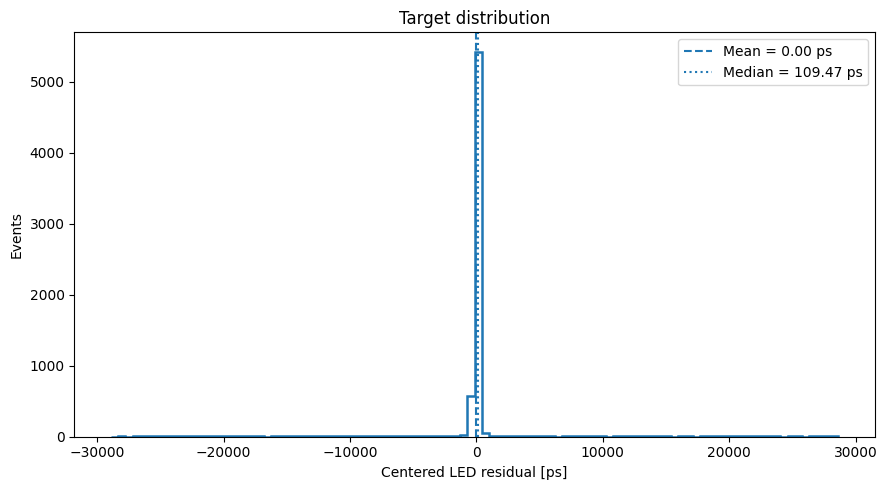

In [59]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y,
    bins=100,
    histtype="step",
    linewidth=1.8,
)

ax.axvline(
    y.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {y.mean():.2f} ps",
)

ax.axvline(
    y.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {y.median():.2f} ps",
)

ax.set_xlabel("Centered LED residual [ps]")
ax.set_ylabel("Events")
ax.set_title("Target distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# ------------------------------------------------------------------
# Target outlier rejection using standard z-score and MAD distance
# ------------------------------------------------------------------

Z_THRESHOLD = 3.0
MAD_THRESHOLD =5.0

# Available options:
#   "zscore" -> reject using only standard z-score
#   "mad"    -> reject using only robust MAD distance
#   "either" -> reject if either criterion identifies the event
#   "both"   -> reject only if both criteria identify the event
OUTLIER_METHOD = "mad"

target_values = analysis_df[TARGET_COLUMN].astype(float)

# ------------------------------------------------------------------
# Standard z-score
# ------------------------------------------------------------------

target_mean = target_values.mean()
target_std = target_values.std(ddof=1)

print("target_mean",target_mean,"target_std",target_std)

if not np.isfinite(target_std) or target_std <= 0:
    raise ValueError(
        "Cannot calculate target z-scores because the target "
        "standard deviation is zero or invalid."
    )

standard_z_score = (
    target_values - target_mean
) / target_std

zscore_outlier_mask = (
    standard_z_score.abs() > Z_THRESHOLD
)

# ------------------------------------------------------------------
# Robust MAD distance
# ------------------------------------------------------------------

target_median = target_values.median()

target_mad = np.median(
    np.abs(target_values - target_median)
)

# 1.4826 converts MAD to a standard-deviation-equivalent scale
# for an approximately Gaussian distribution.
robust_scale = 1.4826 * target_mad

if not np.isfinite(robust_scale) or robust_scale <= 0:
    print(
        "Warning: target MAD is zero or invalid. "
        "MAD rejection will not remove any event."
    )

    mad_distance = pd.Series(
        np.zeros(len(target_values)),
        index=target_values.index,
        dtype=float,
    )

    mad_outlier_mask = pd.Series(
        False,
        index=target_values.index,
    )

else:
    mad_distance = (
        np.abs(target_values - target_median)
        / robust_scale
    )

    mad_outlier_mask = (
        mad_distance > MAD_THRESHOLD
    )

# ------------------------------------------------------------------
# Combine criteria
# ------------------------------------------------------------------

if OUTLIER_METHOD == "zscore":
    target_outlier_mask = zscore_outlier_mask

elif OUTLIER_METHOD == "mad":
    target_outlier_mask = mad_outlier_mask

elif OUTLIER_METHOD == "either":
    target_outlier_mask = (
        zscore_outlier_mask | mad_outlier_mask
    )

elif OUTLIER_METHOD == "both":
    target_outlier_mask = (
        zscore_outlier_mask & mad_outlier_mask
    )

else:
    raise ValueError(
        "OUTLIER_METHOD must be one of: "
        "'zscore', 'mad', 'either', 'both'."
    )

target_inlier_mask = ~target_outlier_mask

# Keep a copy for diagnostics.
analysis_df_before_target_filter = analysis_df.copy()

# Add diagnostic columns only to the diagnostic dataframe.
analysis_df_before_target_filter["target_z_score"] = (
    standard_z_score
)

analysis_df_before_target_filter["target_mad_distance"] = (
    mad_distance
)

analysis_df_before_target_filter["target_is_outlier"] = (
    target_outlier_mask
)

number_before = len(analysis_df)
number_removed = int(target_outlier_mask.sum())
number_after = int(target_inlier_mask.sum())

print("Target outlier rejection")
print("------------------------")
print(f"Method:                {OUTLIER_METHOD}")
print(f"Standard-z threshold:  {Z_THRESHOLD}")
print(f"MAD-distance threshold:{MAD_THRESHOLD}")
print()
print(f"Target mean:           {target_mean:.4f} ps")
print(f"Target standard dev.:  {target_std:.4f} ps")
print(f"Target median:         {target_median:.4f} ps")
print(f"Target MAD:            {target_mad:.4f} ps")
print(f"Robust scale:          {robust_scale:.4f} ps")
print()
print(f"Events before:         {number_before:,}")
print(
    f"Standard-z outliers:   "
    f"{int(zscore_outlier_mask.sum()):,}"
)
print(
    f"MAD-distance outliers: "
    f"{int(mad_outlier_mask.sum()):,}"
)
print(f"Events removed:        {number_removed:,}")
print(f"Events retained:       {number_after:,}")
print(
    f"Retained fraction:     "
    f"{100 * number_after / number_before:.3f}%"
)

# Apply the filter.
analysis_df = (
    analysis_df.loc[target_inlier_mask]
    .reset_index(drop=True)
)

# Recreate X and y after filtering.
X = analysis_df[feature_columns].copy()
y = analysis_df[TARGET_COLUMN].astype(float).copy()

print()
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

target_mean 7.561119848468524e-14 target_std 5213.891960466623
Target outlier rejection
------------------------
Method:                mad
Standard-z threshold:  3.0
MAD-distance threshold:5.0

Target mean:           0.0000 ps
Target standard dev.:  5213.8920 ps
Target median:         109.4726 ps
Target MAD:            27.7070 ps
Robust scale:          41.0784 ps

Events before:         6,736
Standard-z outliers:   309
MAD-distance outliers: 1,808
Events removed:        1,808
Events retained:       4,928
Retained fraction:     73.159%

Final X shape: (4928, 28)
Final y shape: (4928,)


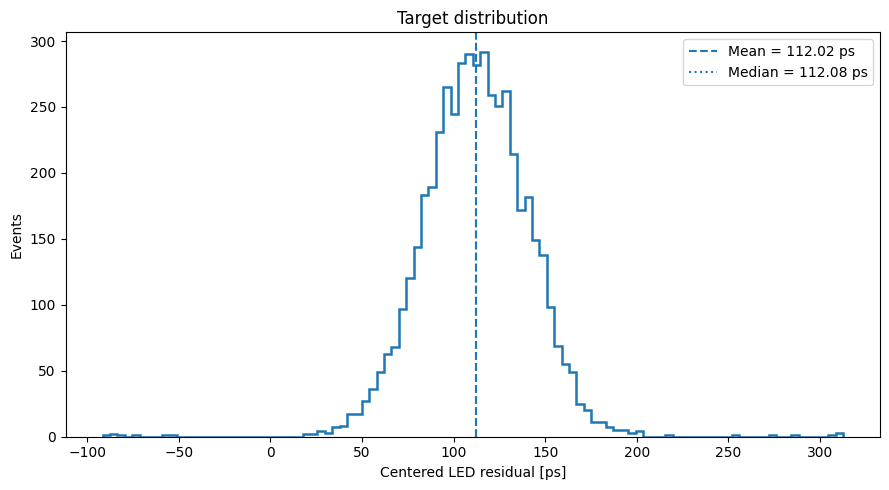

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y,
    bins=100,
    histtype="step",
    linewidth=1.8,
)

ax.axvline(
    y.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {y.mean():.2f} ps",
)

ax.axvline(
    y.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {y.median():.2f} ps",
)

ax.set_xlabel("Centered LED residual [ps]")
ax.set_ylabel("Events")
ax.set_title("Target distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [63]:
# Columns needed for analysis and splitting.
required_columns = (
    feature_columns
    + [TARGET_COLUMN]
    + metadata_columns
)

# Remove duplicates while preserving order.
required_columns = list(dict.fromkeys(required_columns))

working_df = df[required_columns].copy()
working_df = working_df.replace([np.inf, -np.inf], np.nan)

# Remove rows with invalid target.
working_df = (
    working_df.loc[
        working_df[TARGET_COLUMN].notna()
    ]
    .reset_index(drop=True)
)

print(f"Events with valid target: {len(working_df):,}")

Events with valid target: 6,736


In [64]:
# ------------------------------------------------------------------
# Target outlier rejection
# ------------------------------------------------------------------

#Z_THRESHOLD = 5.0
MAD_THRESHOLD = 5.0

# "zscore", "mad", "either", or "both"
OUTLIER_METHOD = "mad"

target_values = working_df[TARGET_COLUMN].astype(float)

# Standard z-score.
target_mean = target_values.mean()
target_std = target_values.std(ddof=1)

if not np.isfinite(target_std) or target_std <= 0:
    raise ValueError(
        "Target standard deviation is zero or invalid."
    )

standard_z_score = (
    target_values - target_mean
) / target_std

zscore_outlier_mask = (
    standard_z_score.abs() > Z_THRESHOLD
)

# Robust MAD distance.
target_median = target_values.median()

target_mad = np.median(
    np.abs(target_values - target_median)
)

robust_scale = 1.4826 * target_mad

if not np.isfinite(robust_scale) or robust_scale <= 0:
    print(
        "Warning: MAD scale is zero or invalid. "
        "MAD filtering is disabled."
    )

    mad_distance = pd.Series(
        0.0,
        index=working_df.index,
    )

    mad_outlier_mask = pd.Series(
        False,
        index=working_df.index,
    )

else:
    mad_distance = (
        np.abs(target_values - target_median)
        / robust_scale
    )

    mad_outlier_mask = (
        mad_distance > MAD_THRESHOLD
    )

# Combine masks.
if OUTLIER_METHOD == "zscore":
    target_outlier_mask = zscore_outlier_mask

elif OUTLIER_METHOD == "mad":
    target_outlier_mask = mad_outlier_mask

elif OUTLIER_METHOD == "either":
    target_outlier_mask = (
        zscore_outlier_mask | mad_outlier_mask
    )

elif OUTLIER_METHOD == "both":
    target_outlier_mask = (
        zscore_outlier_mask & mad_outlier_mask
    )

else:
    raise ValueError(
        "OUTLIER_METHOD must be one of: "
        "'zscore', 'mad', 'either', 'both'."
    )

# Save diagnostics before filtering.
outlier_diagnostics_df = working_df.copy()
outlier_diagnostics_df["target_z_score"] = (
    standard_z_score
)
outlier_diagnostics_df["target_mad_distance"] = (
    mad_distance
)
outlier_diagnostics_df["target_is_outlier"] = (
    target_outlier_mask
)

number_before = len(working_df)
number_removed = int(target_outlier_mask.sum())

# Apply the filter to features, target, and metadata together.
working_df = (
    working_df.loc[~target_outlier_mask]
    .reset_index(drop=True)
)

print(f"Events before filtering: {number_before:,}")
print(f"Events removed:          {number_removed:,}")
print(f"Events retained:         {len(working_df):,}")

Events before filtering: 6,736
Events removed:          1,808
Events retained:         4,928


In [65]:
X = working_df[feature_columns].copy()
y = working_df[TARGET_COLUMN].astype(float).copy()

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

Final X shape: (4928, 28)
Final y shape: (4928,)


In [66]:
GROUP_COLUMN = "meta_source_file_id"

if (
    GROUP_COLUMN in working_df.columns
    and working_df[GROUP_COLUMN].nunique() > 1
):
    groups = (
        working_df[GROUP_COLUMN]
        .reset_index(drop=True)
    )

    # Defensive consistency check.
    assert len(X) == len(y) == len(groups), (
        f"Inconsistent lengths: "
        f"X={len(X)}, y={len(y)}, groups={len(groups)}"
    )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    train_indices, test_indices = next(
        splitter.split(
            X,
            y,
            groups=groups,
        )
    )

    X_train = X.iloc[train_indices].copy()
    X_test = X.iloc[test_indices].copy()

    y_train = y.iloc[train_indices].copy()
    y_test = y.iloc[test_indices].copy()

    groups_train = groups.iloc[train_indices].copy()
    groups_test = groups.iloc[test_indices].copy()

    print(
        f"Split strategy: grouped by {GROUP_COLUMN}"
    )
    print(
        f"Training groups: {groups_train.nunique()}"
    )
    print(
        f"Test groups:     {groups_test.nunique()}"
    )

else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    print(
        "Split strategy: random event split because "
        "fewer than two source groups are available."
    )

print(f"Training events: {len(X_train):,}")
print(f"Test events:     {len(X_test):,}")

Split strategy: grouped by meta_source_file_id
Training groups: 3696
Test groups:     1232
Training events: 3,696
Test events:     1,232


In [69]:
pca_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

X_scaled = pca_preprocessor.fit_transform(X)

print(f"Standardized matrix shape: {X_scaled.shape}")

Standardized matrix shape: (4928, 28)


In [70]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_df = pd.DataFrame(
    {
        "component": np.arange(
            1,
            len(pca.explained_variance_ratio_) + 1,
        ),
        "explained_variance_ratio": (
            pca.explained_variance_ratio_
        ),
        "cumulative_explained_variance": np.cumsum(
            pca.explained_variance_ratio_
        ),
    }
)

display(explained_variance_df.head(15))

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.373486,0.373486
1,2,0.075408,0.448894
2,3,0.072534,0.521427
3,4,0.046750,0.568177
4,5,0.042871,0.611048
5,6,0.039340,0.650388
6,7,0.038610,0.688998
7,8,0.036449,0.725447
8,9,0.036125,0.761573
9,10,0.035580,0.797153


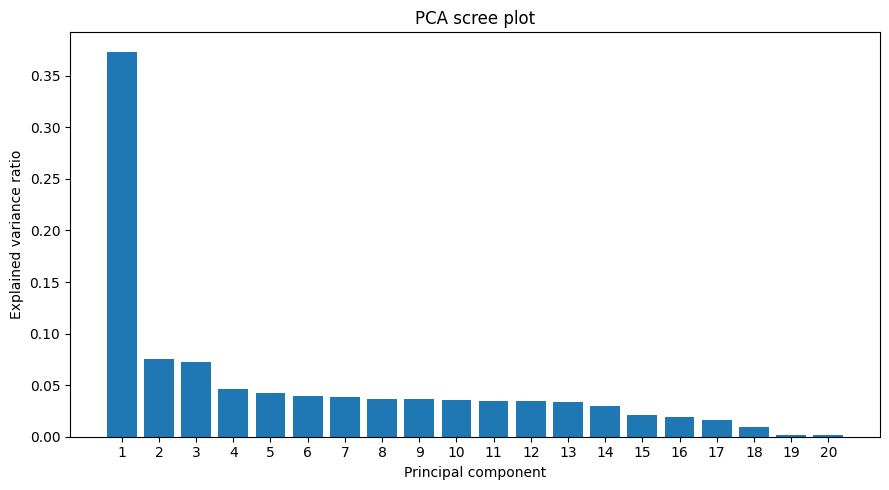

In [71]:
number_to_plot = min(
    20,
    len(pca.explained_variance_ratio_),
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    explained_variance_df["component"][:number_to_plot],
    explained_variance_df[
        "explained_variance_ratio"
    ][:number_to_plot],
)

ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree plot")
ax.set_xticks(
    explained_variance_df["component"][:number_to_plot]
)

plt.tight_layout()
plt.show()

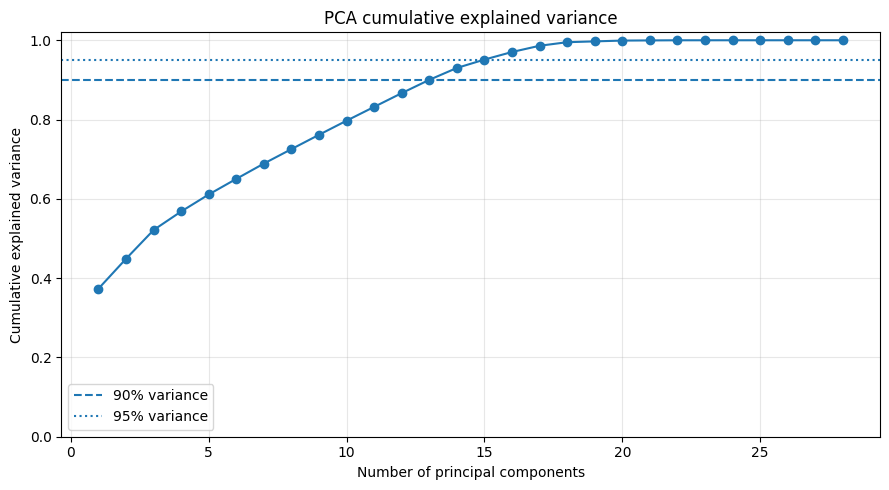

In [72]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    explained_variance_df["component"],
    explained_variance_df[
        "cumulative_explained_variance"
    ],
    marker="o",
)

ax.axhline(
    0.90,
    linestyle="--",
    label="90% variance",
)

ax.axhline(
    0.95,
    linestyle=":",
    label="95% variance",
)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.02)
ax.set_title("PCA cumulative explained variance")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

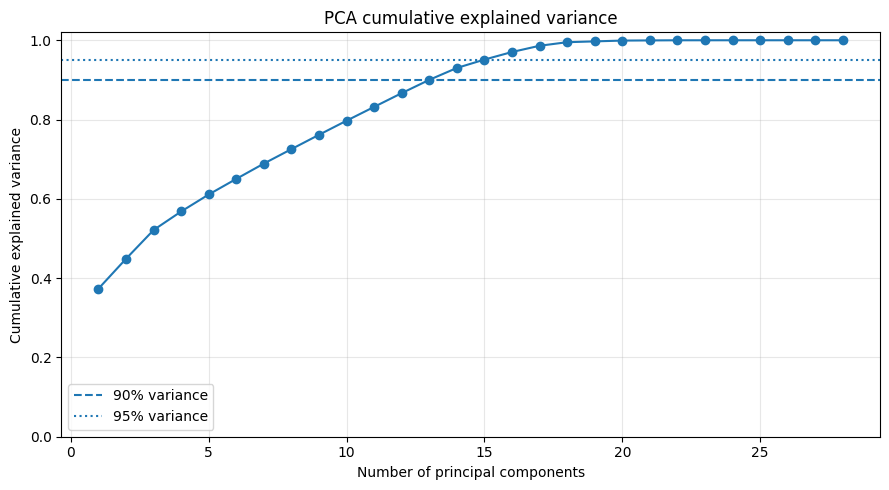

In [73]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    explained_variance_df["component"],
    explained_variance_df[
        "cumulative_explained_variance"
    ],
    marker="o",
)

ax.axhline(
    0.90,
    linestyle="--",
    label="90% variance",
)

ax.axhline(
    0.95,
    linestyle=":",
    label="95% variance",
)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.02)
ax.set_title("PCA cumulative explained variance")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

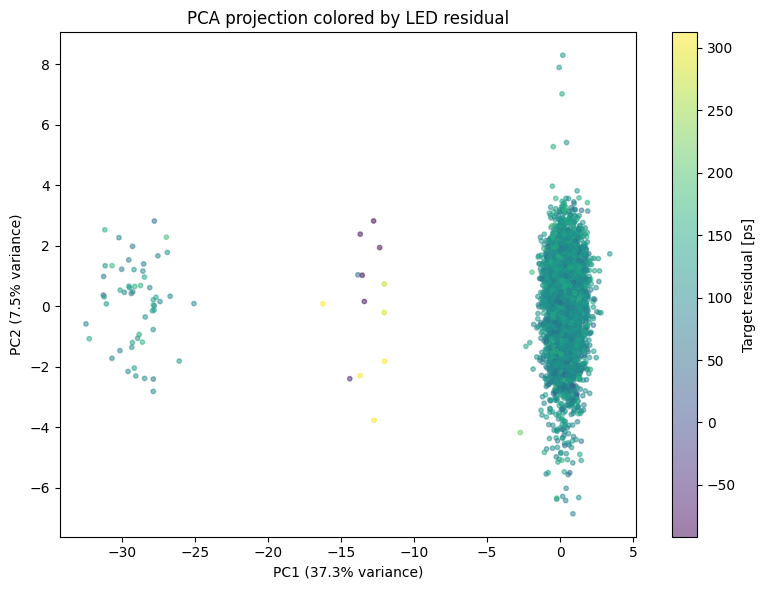

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=10,
    alpha=0.5,
)

ax.set_xlabel(
    "PC1 "
    f"({100 * pca.explained_variance_ratio_[0]:.1f}% variance)"
)

ax.set_ylabel(
    "PC2 "
    f"({100 * pca.explained_variance_ratio_[1]:.1f}% variance)"
)

ax.set_title("PCA projection colored by LED residual")

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Target residual [ps]")

plt.tight_layout()
plt.show()

In [75]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=[
        f"PC{index + 1}"
        for index in range(pca.n_components_)
    ],
)

display(loadings_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
energy_ch1_max_amplitude_mV,0.005144,-0.044887,0.187872,0.185497,-0.240402,-0.329493,-0.088198,0.081790,0.288010,0.077161,...,-0.006381,-0.001546,-0.001852,0.002093,-0.000264,-0.000241,0.000438,0.000167,0.000000e+00,-0.000000e+00
energy_ch1_noise_rms_mV,0.004848,0.007165,-0.040970,-0.024663,0.094774,-0.003613,0.083291,0.223013,-0.200237,0.910127,...,0.000691,0.005401,0.000797,0.000062,-0.000167,-0.000087,-0.000171,-0.000078,-7.239715e-17,4.746838e-16
energy_ch1_rise_t05_to_t50_ps,0.006538,-0.234377,0.651951,-0.033449,0.021700,0.049942,0.021183,-0.019548,-0.033028,0.012018,...,-0.001017,-0.000700,0.000455,-0.001705,-0.000256,-0.000189,0.000029,0.000143,3.161574e-02,7.042244e-01
energy_ch1_t05_minus_timing_ch3_led_ps,-0.197493,0.024594,-0.041457,-0.215873,0.206899,0.115647,-0.049181,0.016861,-0.079815,-0.065587,...,0.010263,0.000937,-0.001992,-0.004735,0.000476,-0.000136,-0.000291,-0.001240,3.931090e-03,8.756300e-02
energy_ch1_t50_minus_timing_ch3_led_ps,-0.018046,-0.231680,0.647805,-0.060385,0.047500,0.064422,0.015091,-0.017478,-0.043019,0.003869,...,0.000259,-0.000584,0.000207,-0.002297,-0.000197,-0.000207,-0.000007,-0.000011,-3.156653e-02,-7.031282e-01


In [76]:
def top_loadings(
    loadings: pd.DataFrame,
    component: str,
    top_n: int = 15,
) -> pd.DataFrame:
    result = pd.DataFrame(
        {
            "feature": loadings.index,
            "loading": loadings[component].to_numpy(),
        }
    )

    result["absolute_loading"] = result["loading"].abs()

    return (
        result
        .sort_values("absolute_loading", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


for component in ["PC1", "PC2", "PC3"]:
    print(component)
    display(
        top_loadings(
            loadings_df,
            component,
            top_n=TOP_N_FEATURES,
        )
    )

PC1


,feature,loading,absolute_loading
0,timing_ch3_poly_c0,0.290668,0.290668
1,timing_ch4_poly_c0,0.290272,0.290272
2,timing_ch3_poly_c2,-0.290154,0.290154
3,timing_ch4_poly_c2,-0.289720,0.289720
4,timing_ch3_poly_c4,0.289020,0.289020
5,timing_ch4_poly_c4,0.288421,0.288421
6,timing_ch3_poly_c3,-0.250360,0.250360
7,timing_ch4_poly_c1,0.248449,0.248449
8,timing_ch3_poly_c1,0.247947,0.247947
9,timing_ch4_poly_c3,-0.247904,0.247904


PC2


,feature,loading,absolute_loading
0,energy_ch2_rise_t05_to_t50_ps,0.635151,0.635151
1,energy_ch2_t50_minus_timing_ch4_led_ps,0.625003,0.625003
2,energy_ch2_max_amplitude_mV,0.273582,0.273582
3,energy_ch1_rise_t05_to_t50_ps,-0.234377,0.234377
4,energy_ch1_t50_minus_timing_ch3_led_ps,-0.231680,0.231680
5,energy_ch2_t05_minus_timing_ch4_led_ps,-0.109827,0.109827
6,timing_ch4_max_amplitude_mV,-0.048190,0.048190
7,energy_ch1_max_amplitude_mV,-0.044887,0.044887
8,timing_ch4_poly_rmse_mV,0.034867,0.034867
9,timing_ch4_poly_r2,-0.034593,0.034593


PC3


,feature,loading,absolute_loading
0,energy_ch1_rise_t05_to_t50_ps,0.651951,0.651951
1,energy_ch1_t50_minus_timing_ch3_led_ps,0.647805,0.647805
2,energy_ch2_rise_t05_to_t50_ps,0.224040,0.224040
3,energy_ch2_t50_minus_timing_ch4_led_ps,0.219639,0.219639
4,energy_ch1_max_amplitude_mV,0.187872,0.187872
5,energy_ch2_max_amplitude_mV,0.108631,0.108631
6,energy_ch2_t05_minus_timing_ch4_led_ps,-0.044730,0.044730
7,energy_ch1_t05_minus_timing_ch3_led_ps,-0.041457,0.041457
8,energy_ch1_noise_rms_mV,-0.040970,0.040970
9,timing_ch4_noise_rms_mV,0.040817,0.040817


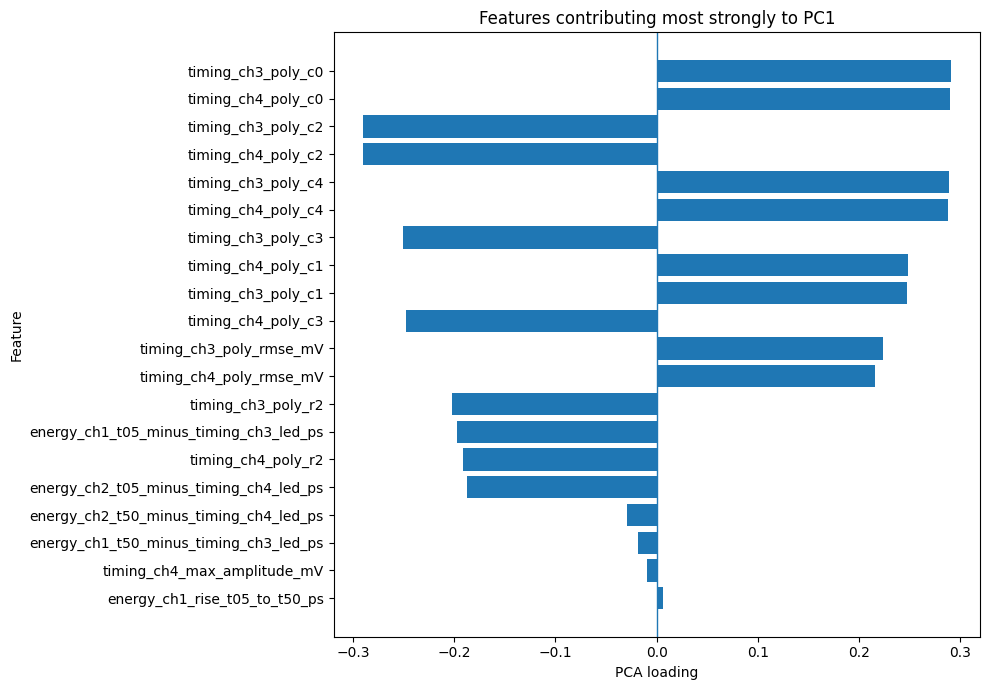

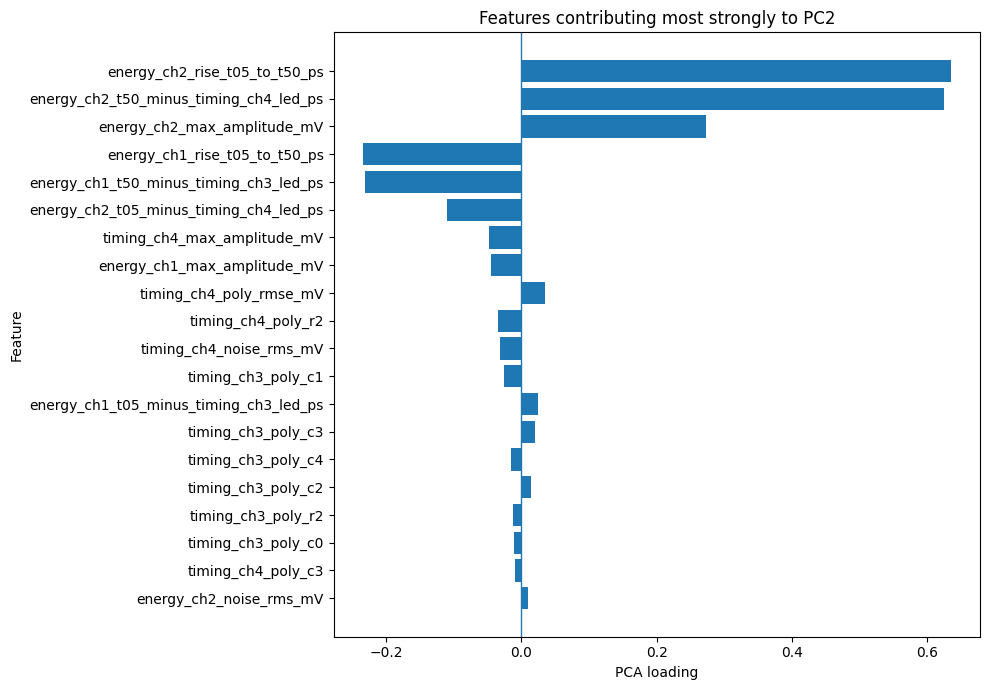

In [77]:
for component in ["PC1", "PC2"]:
    plot_df = (
        top_loadings(
            loadings_df,
            component,
            top_n=TOP_N_FEATURES,
        )
        .sort_values("absolute_loading")
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(
        plot_df["feature"],
        plot_df["loading"],
    )

    ax.axvline(0.0, linewidth=1.0)
    ax.set_xlabel("PCA loading")
    ax.set_ylabel("Feature")
    ax.set_title(
        f"Features contributing most strongly to {component}"
    )

    plt.tight_layout()
    plt.show()

In [79]:
pc_target_rows = []

for component_index in range(X_pca.shape[1]):
    pc_values = X_pca[:, component_index]

    pearson_correlation = np.corrcoef(
        pc_values,
        y.to_numpy(),
    )[0, 1]

    pc_target_rows.append(
        {
            "component": component_index + 1,
            "explained_variance_ratio": (
                pca.explained_variance_ratio_[component_index]
            ),
            "target_correlation": pearson_correlation,
            "absolute_target_correlation": abs(
                pearson_correlation
            ),
        }
    )

pc_target_df = (
    pd.DataFrame(pc_target_rows)
    .sort_values(
        "absolute_target_correlation",
        ascending=False,
    )
)

display(pc_target_df.head(15))

,component,explained_variance_ratio,target_correlation,absolute_target_correlation
17,18,0.008997,0.222339,0.222339
11,12,0.034685,-0.203201,0.203201
13,14,0.029985,0.135620,0.135620
12,13,0.033497,-0.123112,0.123112
26,27,0.000000,0.115232,0.115232
25,26,0.000002,0.096826,0.096826
27,28,0.000000,0.093801,0.093801
8,9,0.036125,-0.080314,0.080314
1,2,0.075408,0.077553,0.077553
23,24,0.000018,-0.076532,0.076532


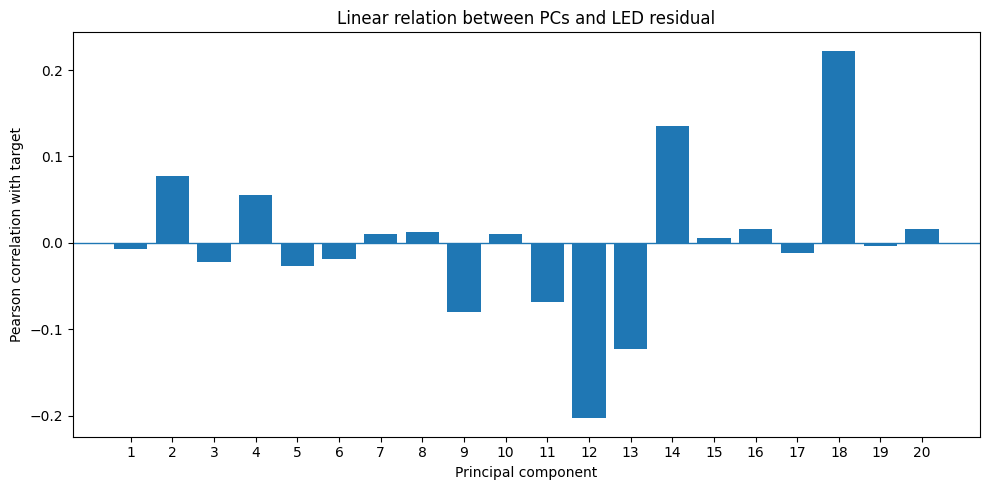

In [80]:
number_to_plot = min(20, len(pc_target_rows))

plot_df = (
    pd.DataFrame(pc_target_rows)
    .head(number_to_plot)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    plot_df["component"],
    plot_df["target_correlation"],
)

ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("Principal component")
ax.set_ylabel("Pearson correlation with target")
ax.set_title("Linear relation between PCs and LED residual")
ax.set_xticks(plot_df["component"])

plt.tight_layout()
plt.show()

# Decision Tree  

In [84]:
GROUP_COLUMN = "meta_source_file_id"

if (
    GROUP_COLUMN in working_df.columns
    and working_df[GROUP_COLUMN].nunique() > 1
):
    groups = (
        working_df[GROUP_COLUMN]
        .reset_index(drop=True)
    )

    # Defensive consistency check.
    assert len(X) == len(y) == len(groups), (
        f"Inconsistent lengths: "
        f"X={len(X)}, y={len(y)}, groups={len(groups)}"
    )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    train_indices, test_indices = next(
        splitter.split(
            X,
            y,
            groups=groups,
        )
    )

    X_train = X.iloc[train_indices].copy()
    X_test = X.iloc[test_indices].copy()

    y_train = y.iloc[train_indices].copy()
    y_test = y.iloc[test_indices].copy()

    groups_train = groups.iloc[train_indices].copy()
    groups_test = groups.iloc[test_indices].copy()

    print(
        f"Split strategy: grouped by {GROUP_COLUMN}"
    )
    print(
        f"Training groups: {groups_train.nunique()}"
    )
    print(
        f"Test groups:     {groups_test.nunique()}"
    )

else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    print(
        "Split strategy: random event split because "
        "fewer than two source groups are available."
    )

print(f"Training events: {len(X_train):,}")
print(f"Test events:     {len(X_test):,}")

Split strategy: grouped by meta_source_file_id
Training groups: 3696
Test groups:     1232
Training events: 3,696
Test events:     1,232


In [85]:
def regression_metrics(
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """Return common regression metrics."""

    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    return {
        "rmse_ps": np.sqrt(
            mean_squared_error(y_true_array, y_pred_array)
        ),
        "mae_ps": mean_absolute_error(
            y_true_array,
            y_pred_array,
        ),
        "r2": r2_score(
            y_true_array,
            y_pred_array,
        ),
        "residual_std_ps": np.std(
            y_true_array - y_pred_array,
            ddof=1,
        ),
    }

In [86]:
depth_results = []

for depth in DEPTH_VALUES:
    model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "regressor",
                DecisionTreeRegressor(
                    max_depth=depth,
                    min_samples_leaf=20,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_metrics = regression_metrics(
        y_train,
        train_prediction,
    )
    test_metrics = regression_metrics(
        y_test,
        test_prediction,
    )

    depth_results.append(
        {
            "max_depth": depth,
            "train_rmse_ps": train_metrics["rmse_ps"],
            "test_rmse_ps": test_metrics["rmse_ps"],
            "train_mae_ps": train_metrics["mae_ps"],
            "test_mae_ps": test_metrics["mae_ps"],
            "train_r2": train_metrics["r2"],
            "test_r2": test_metrics["r2"],
            "train_residual_std_ps": train_metrics[
                "residual_std_ps"
            ],
            "test_residual_std_ps": test_metrics[
                "residual_std_ps"
            ],
        }
    )

depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df)

,max_depth,train_rmse_ps,test_rmse_ps,train_mae_ps,test_mae_ps,train_r2,test_r2,train_residual_std_ps,test_residual_std_ps
0,1,28.749862,28.805472,21.978140,22.437095,0.025903,-0.007984,28.753752,28.801312
1,2,28.376443,28.440124,21.677904,22.016444,0.051043,0.017423,28.380282,28.437987
2,3,28.061971,28.575935,21.532997,22.114486,0.071959,0.008016,28.065768,28.575037
3,4,27.704265,28.900971,21.406182,22.380982,0.095468,-0.014679,27.708014,28.906835
4,5,27.395375,29.205793,21.144906,22.595454,0.115526,-0.036196,27.399082,29.214341
5,6,27.000982,29.387403,20.855628,22.794011,0.140809,-0.049123,27.004635,29.394514
6,7,26.519922,29.919711,20.497406,23.363543,0.171152,-0.087473,26.523510,29.923010
7,8,26.013504,30.310852,20.114925,23.678215,0.202504,-0.116092,26.017024,30.317991
8,9,25.628333,30.641882,19.743656,24.017915,0.225946,-0.140603,25.631801,30.646927
9,10,25.274123,30.953890,19.410405,24.294685,0.247194,-0.163950,25.277543,30.962597


In [87]:
best_depth_row = depth_results_df.loc[
    depth_results_df["test_rmse_ps"].idxmin()
]

best_depth = int(best_depth_row["max_depth"])

print(f"Best depth by test RMSE: {best_depth}")
display(best_depth_row.to_frame("value"))

Best depth by test RMSE: 2


,value
max_depth,2.000000
train_rmse_ps,28.376443
test_rmse_ps,28.440124
train_mae_ps,21.677904
test_mae_ps,22.016444
train_r2,0.051043
test_r2,0.017423
train_residual_std_ps,28.380282
test_residual_std_ps,28.437987


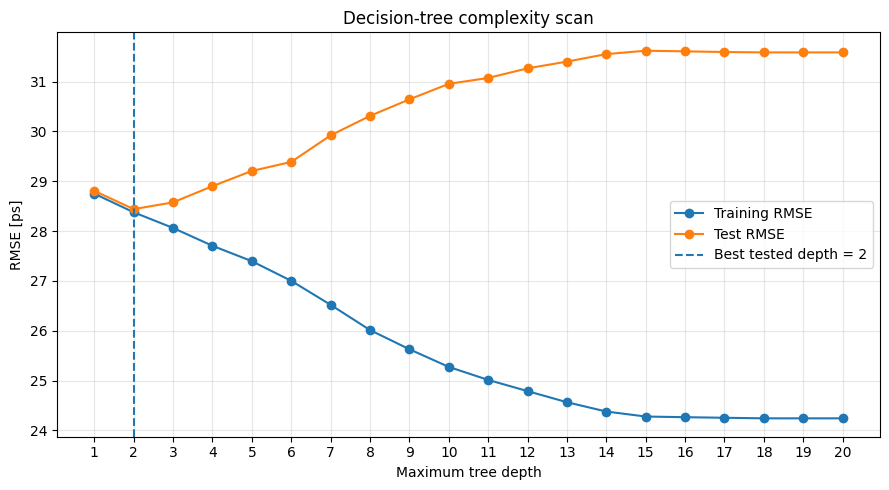

In [88]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["train_rmse_ps"],
    marker="o",
    label="Training RMSE",
)

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["test_rmse_ps"],
    marker="o",
    label="Test RMSE",
)

ax.axvline(
    best_depth,
    linestyle="--",
    label=f"Best tested depth = {best_depth}",
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("RMSE [ps]")
ax.set_title("Decision-tree complexity scan")
ax.set_xticks(DEPTH_VALUES)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

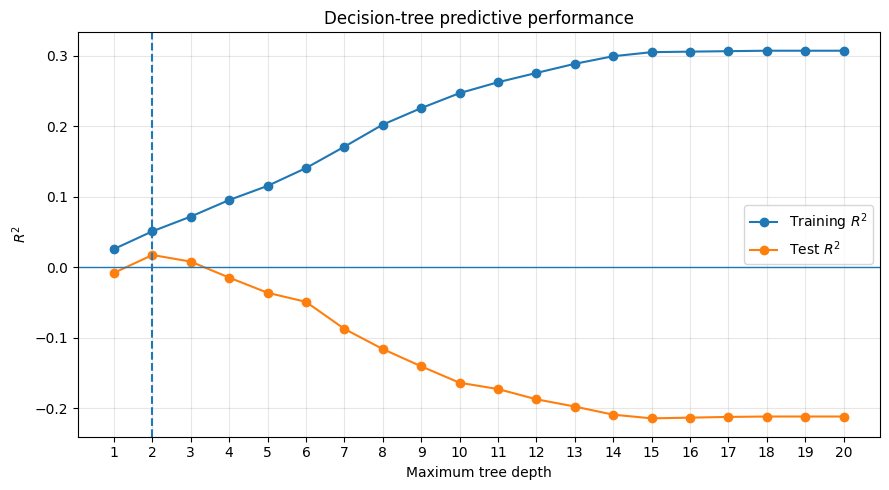

In [89]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["train_r2"],
    marker="o",
    label="Training $R^2$",
)

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["test_r2"],
    marker="o",
    label="Test $R^2$",
)

ax.axhline(0.0, linewidth=1.0)
ax.axvline(best_depth, linestyle="--")

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("$R^2$")
ax.set_title("Decision-tree predictive performance")
ax.set_xticks(DEPTH_VALUES)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [90]:
SELECTED_DEPTH = MAX_DEPTH
# SELECTED_DEPTH = best_depth

tree_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "regressor",
            DecisionTreeRegressor(
                max_depth=SELECTED_DEPTH,
                min_samples_leaf=20,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

tree_pipeline.fit(X_train, y_train)

train_prediction = tree_pipeline.predict(X_train)
test_prediction = tree_pipeline.predict(X_test)

train_metrics = regression_metrics(
    y_train,
    train_prediction,
)

test_metrics = regression_metrics(
    y_test,
    test_prediction,
)

metrics_df = pd.DataFrame(
    {
        "train": train_metrics,
        "test": test_metrics,
    }
)

display(metrics_df)

,train,test
rmse_ps,27.704265,28.900971
mae_ps,21.406182,22.380982
r2,0.095468,-0.014679
residual_std_ps,27.708014,28.906835


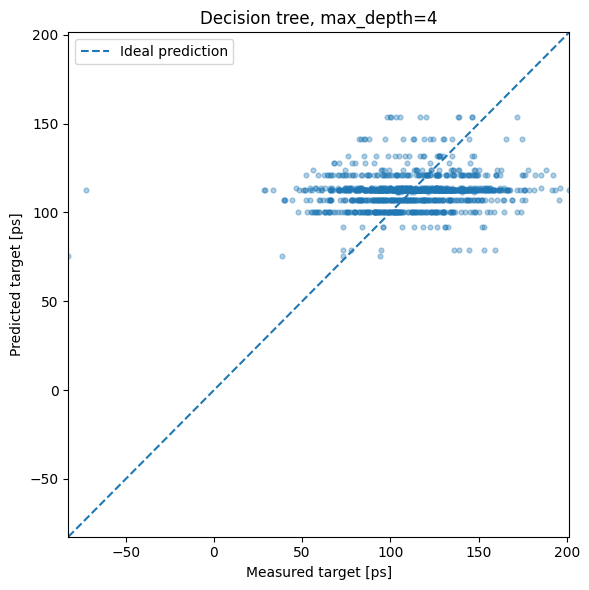

In [91]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    y_test,
    test_prediction,
    s=12,
    alpha=0.35,
)

limits = [
    min(y_test.min(), test_prediction.min()),
    max(y_test.max(), test_prediction.max()),
]

ax.plot(
    limits,
    limits,
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction",
)

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("Measured target [ps]")
ax.set_ylabel("Predicted target [ps]")
ax.set_title(
    f"Decision tree, max_depth={SELECTED_DEPTH}"
)
ax.legend()

plt.tight_layout()
plt.show()

In [92]:
corrected_test_residual = (
    y_test.to_numpy() - test_prediction
)

original_std = np.std(y_test, ddof=1)
corrected_std = np.std(corrected_test_residual, ddof=1)

print(f"Original test standard deviation:  {original_std:.3f} ps")
print(f"Corrected test standard deviation: {corrected_std:.3f} ps")
print(
    "Relative standard-deviation reduction: "
    f"{100 * (1 - corrected_std / original_std):.2f}%"
)

Original test standard deviation:  28.703 ps
Corrected test standard deviation: 28.907 ps
Relative standard-deviation reduction: -0.71%


In [93]:
corrected_test_residual = (
    y_test.to_numpy() - test_prediction
)

original_std = np.std(y_test, ddof=1)
corrected_std = np.std(corrected_test_residual, ddof=1)

print(f"Original test standard deviation:  {original_std:.3f} ps")
print(f"Corrected test standard deviation: {corrected_std:.3f} ps")
print(
    "Relative standard-deviation reduction: "
    f"{100 * (1 - corrected_std / original_std):.2f}%"
)

Original test standard deviation:  28.703 ps
Corrected test standard deviation: 28.907 ps
Relative standard-deviation reduction: -0.71%


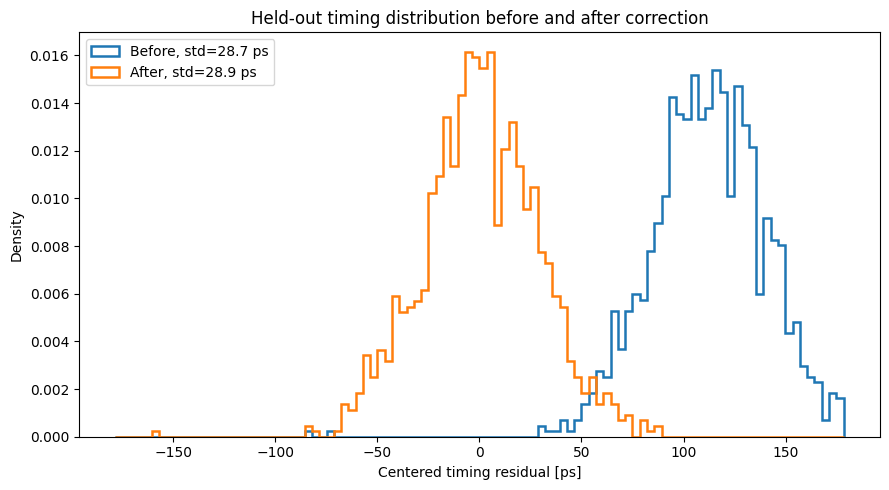

In [94]:
common_limit = np.percentile(
    np.abs(
        np.concatenate(
            [
                y_test.to_numpy(),
                corrected_test_residual,
            ]
        )
    ),
    99.5,
)

bins = np.linspace(
    -common_limit,
    common_limit,
    101,
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y_test,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    density=True,
    label=f"Before, std={original_std:.1f} ps",
)

ax.hist(
    corrected_test_residual,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    density=True,
    label=f"After, std={corrected_std:.1f} ps",
)

ax.set_xlabel("Centered timing residual [ps]")
ax.set_ylabel("Density")
ax.set_title("Held-out timing distribution before and after correction")
ax.legend()

plt.tight_layout()
plt.show()

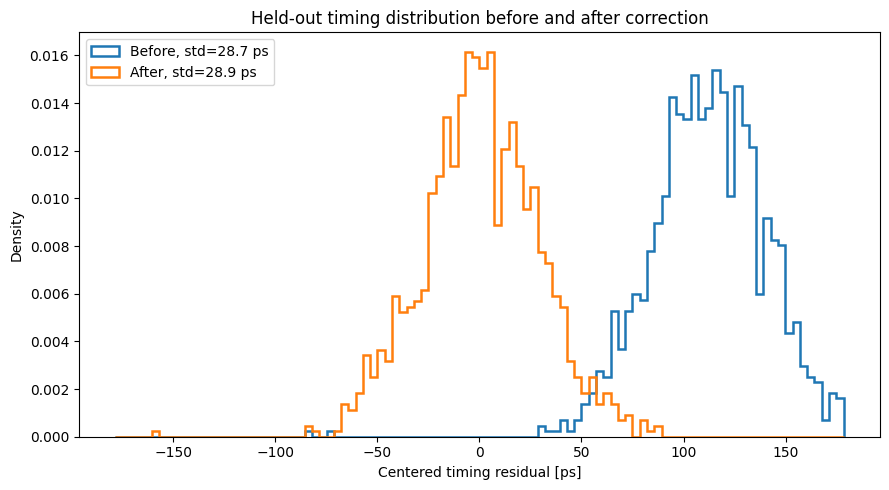

In [95]:
common_limit = np.percentile(
    np.abs(
        np.concatenate(
            [
                y_test.to_numpy(),
                corrected_test_residual,
            ]
        )
    ),
    99.5,
)

bins = np.linspace(
    -common_limit,
    common_limit,
    101,
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y_test,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    density=True,
    label=f"Before, std={original_std:.1f} ps",
)

ax.hist(
    corrected_test_residual,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    density=True,
    label=f"After, std={corrected_std:.1f} ps",
)

ax.set_xlabel("Centered timing residual [ps]")
ax.set_ylabel("Density")
ax.set_title("Held-out timing distribution before and after correction")
ax.legend()

plt.tight_layout()
plt.show()

In [96]:
tree_model = tree_pipeline.named_steps["regressor"]

impurity_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": tree_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(impurity_importance_df.head(TOP_N_FEATURES))

,feature,importance
0,energy_ch2_max_amplitude_mV,0.369806
1,energy_ch1_max_amplitude_mV,0.263333
2,energy_ch1_t05_minus_timing_ch3_led_ps,0.093154
3,timing_ch3_poly_c1,0.074807
4,timing_ch4_poly_rmse_mV,0.057816
5,timing_ch4_poly_c1,0.057165
6,timing_ch3_poly_c0,0.038123
7,timing_ch4_noise_rms_mV,0.031415
8,timing_ch3_poly_c4,0.014382
9,timing_ch3_poly_r2,0.000000


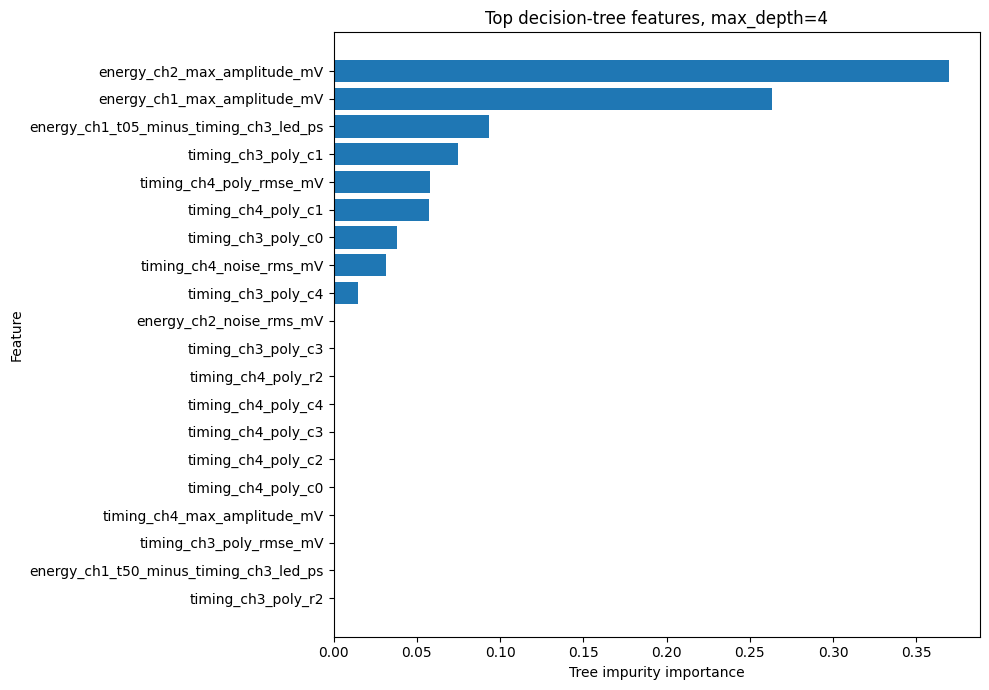

In [97]:
plot_df = (
    impurity_importance_df
    .head(TOP_N_FEATURES)
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df["feature"],
    plot_df["importance"],
)

ax.set_xlabel("Tree impurity importance")
ax.set_ylabel("Feature")
ax.set_title(
    f"Top decision-tree features, max_depth={SELECTED_DEPTH}"
)

plt.tight_layout()
plt.show()

In [99]:
permutation_result = permutation_importance(
    tree_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=N_PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance_mean_ps": permutation_result.importances_mean,
            "importance_std_ps": permutation_result.importances_std,
        }
    )
    .sort_values("importance_mean_ps", ascending=False)
    .reset_index(drop=True)
)

display(
    permutation_importance_df.head(TOP_N_FEATURES)
)

,feature,importance_mean_ps,importance_std_ps
0,energy_ch1_max_amplitude_mV,0.697411,0.136027
1,energy_ch2_max_amplitude_mV,0.401223,0.294935
2,timing_ch3_poly_c0,0.227876,0.060092
3,energy_ch1_noise_rms_mV,0.000000,0.000000
4,timing_ch4_poly_r2,0.000000,0.000000
5,timing_ch4_poly_c4,0.000000,0.000000
6,timing_ch4_poly_c3,0.000000,0.000000
7,timing_ch4_poly_c2,0.000000,0.000000
8,timing_ch4_poly_c0,0.000000,0.000000
9,timing_ch4_max_amplitude_mV,0.000000,0.000000


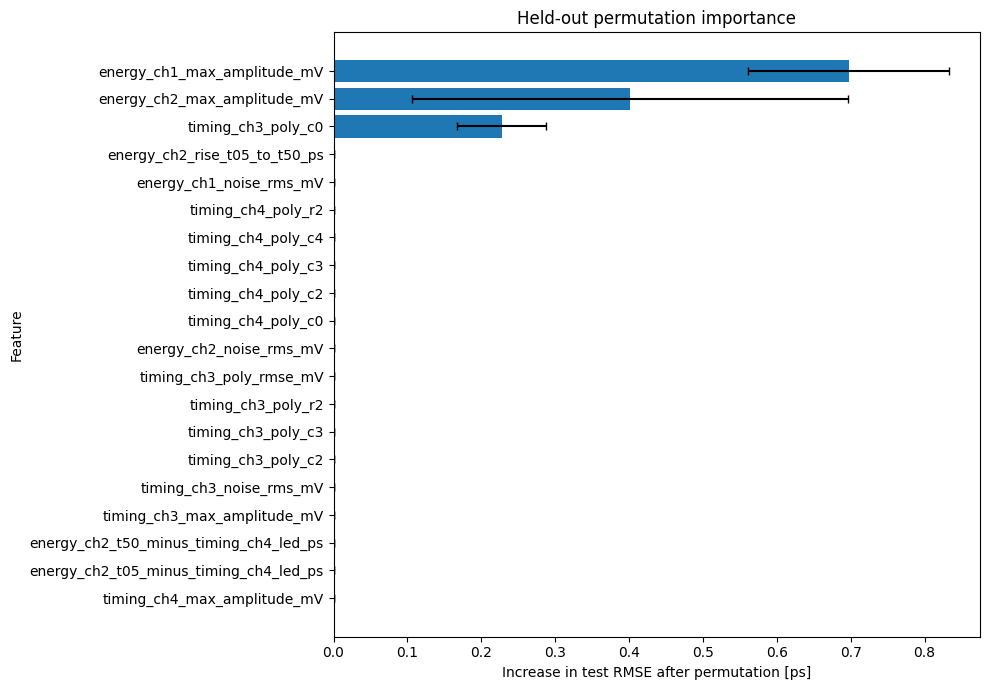

In [100]:
plot_df = (
    permutation_importance_df
    .head(TOP_N_FEATURES)
    .sort_values("importance_mean_ps")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df["feature"],
    plot_df["importance_mean_ps"],
    xerr=plot_df["importance_std_ps"],
    capsize=3,
)

ax.set_xlabel("Increase in test RMSE after permutation [ps]")
ax.set_ylabel("Feature")
ax.set_title("Held-out permutation importance")

plt.tight_layout()
plt.show()

In [101]:
importance_comparison_df = impurity_importance_df.merge(
    permutation_importance_df,
    on="feature",
    how="inner",
)

importance_comparison_df["impurity_rank"] = (
    importance_comparison_df["importance"]
    .rank(ascending=False, method="min")
)

importance_comparison_df["permutation_rank"] = (
    importance_comparison_df["importance_mean_ps"]
    .rank(ascending=False, method="min")
)

importance_comparison_df = importance_comparison_df.sort_values(
    "permutation_rank"
)

display(
    importance_comparison_df[
        [
            "feature",
            "importance",
            "importance_mean_ps",
            "importance_std_ps",
            "impurity_rank",
            "permutation_rank",
        ]
    ].head(TOP_N_FEATURES)
)

,feature,importance,importance_mean_ps,importance_std_ps,impurity_rank,permutation_rank
1,energy_ch1_max_amplitude_mV,0.263333,0.697411,0.136027,2.0,1.0
0,energy_ch2_max_amplitude_mV,0.369806,0.401223,0.294935,1.0,2.0
6,timing_ch3_poly_c0,0.038123,0.227876,0.060092,7.0,3.0
25,energy_ch2_t05_minus_timing_ch4_led_ps,0.000000,0.000000,0.000000,10.0,4.0
24,energy_ch2_t50_minus_timing_ch4_led_ps,0.000000,0.000000,0.000000,10.0,4.0
23,timing_ch3_max_amplitude_mV,0.000000,0.000000,0.000000,10.0,4.0
22,timing_ch3_noise_rms_mV,0.000000,0.000000,0.000000,10.0,4.0
21,energy_ch1_rise_t05_to_t50_ps,0.000000,0.000000,0.000000,10.0,4.0
20,energy_ch1_noise_rms_mV,0.000000,0.000000,0.000000,10.0,4.0
19,timing_ch3_poly_c3,0.000000,0.000000,0.000000,10.0,4.0


In [102]:
def feature_group(feature_name: str) -> str:
    if feature_name.startswith("timing_ch3_poly_c"):
        return "Timing ch3 polynomial"
    if feature_name.startswith("timing_ch4_poly_c"):
        return "Timing ch4 polynomial"
    if feature_name.startswith("timing_ch3"):
        return "Timing ch3 scalar"
    if feature_name.startswith("timing_ch4"):
        return "Timing ch4 scalar"
    if feature_name.startswith("energy_ch1"):
        return "Energy ch1"
    if feature_name.startswith("energy_ch2"):
        return "Energy ch2"
    return "Other"


grouped_importance_df = permutation_importance_df.copy()
grouped_importance_df["group"] = (
    grouped_importance_df["feature"].map(feature_group)
)

grouped_importance_summary = (
    grouped_importance_df
    .groupby("group", as_index=False)
    .agg(
        summed_permutation_importance_ps=(
            "importance_mean_ps",
            "sum",
        ),
        number_of_features=("feature", "count"),
    )
    .sort_values(
        "summed_permutation_importance_ps",
        ascending=False,
    )
)

display(grouped_importance_summary)

,group,summed_permutation_importance_ps,number_of_features
0,Energy ch1,0.641940,5
1,Energy ch2,0.401223,5
2,Timing ch3 polynomial,0.196175,5
3,Timing ch3 scalar,0.000000,4
4,Timing ch4 polynomial,-0.011563,5
5,Timing ch4 scalar,-0.071452,4


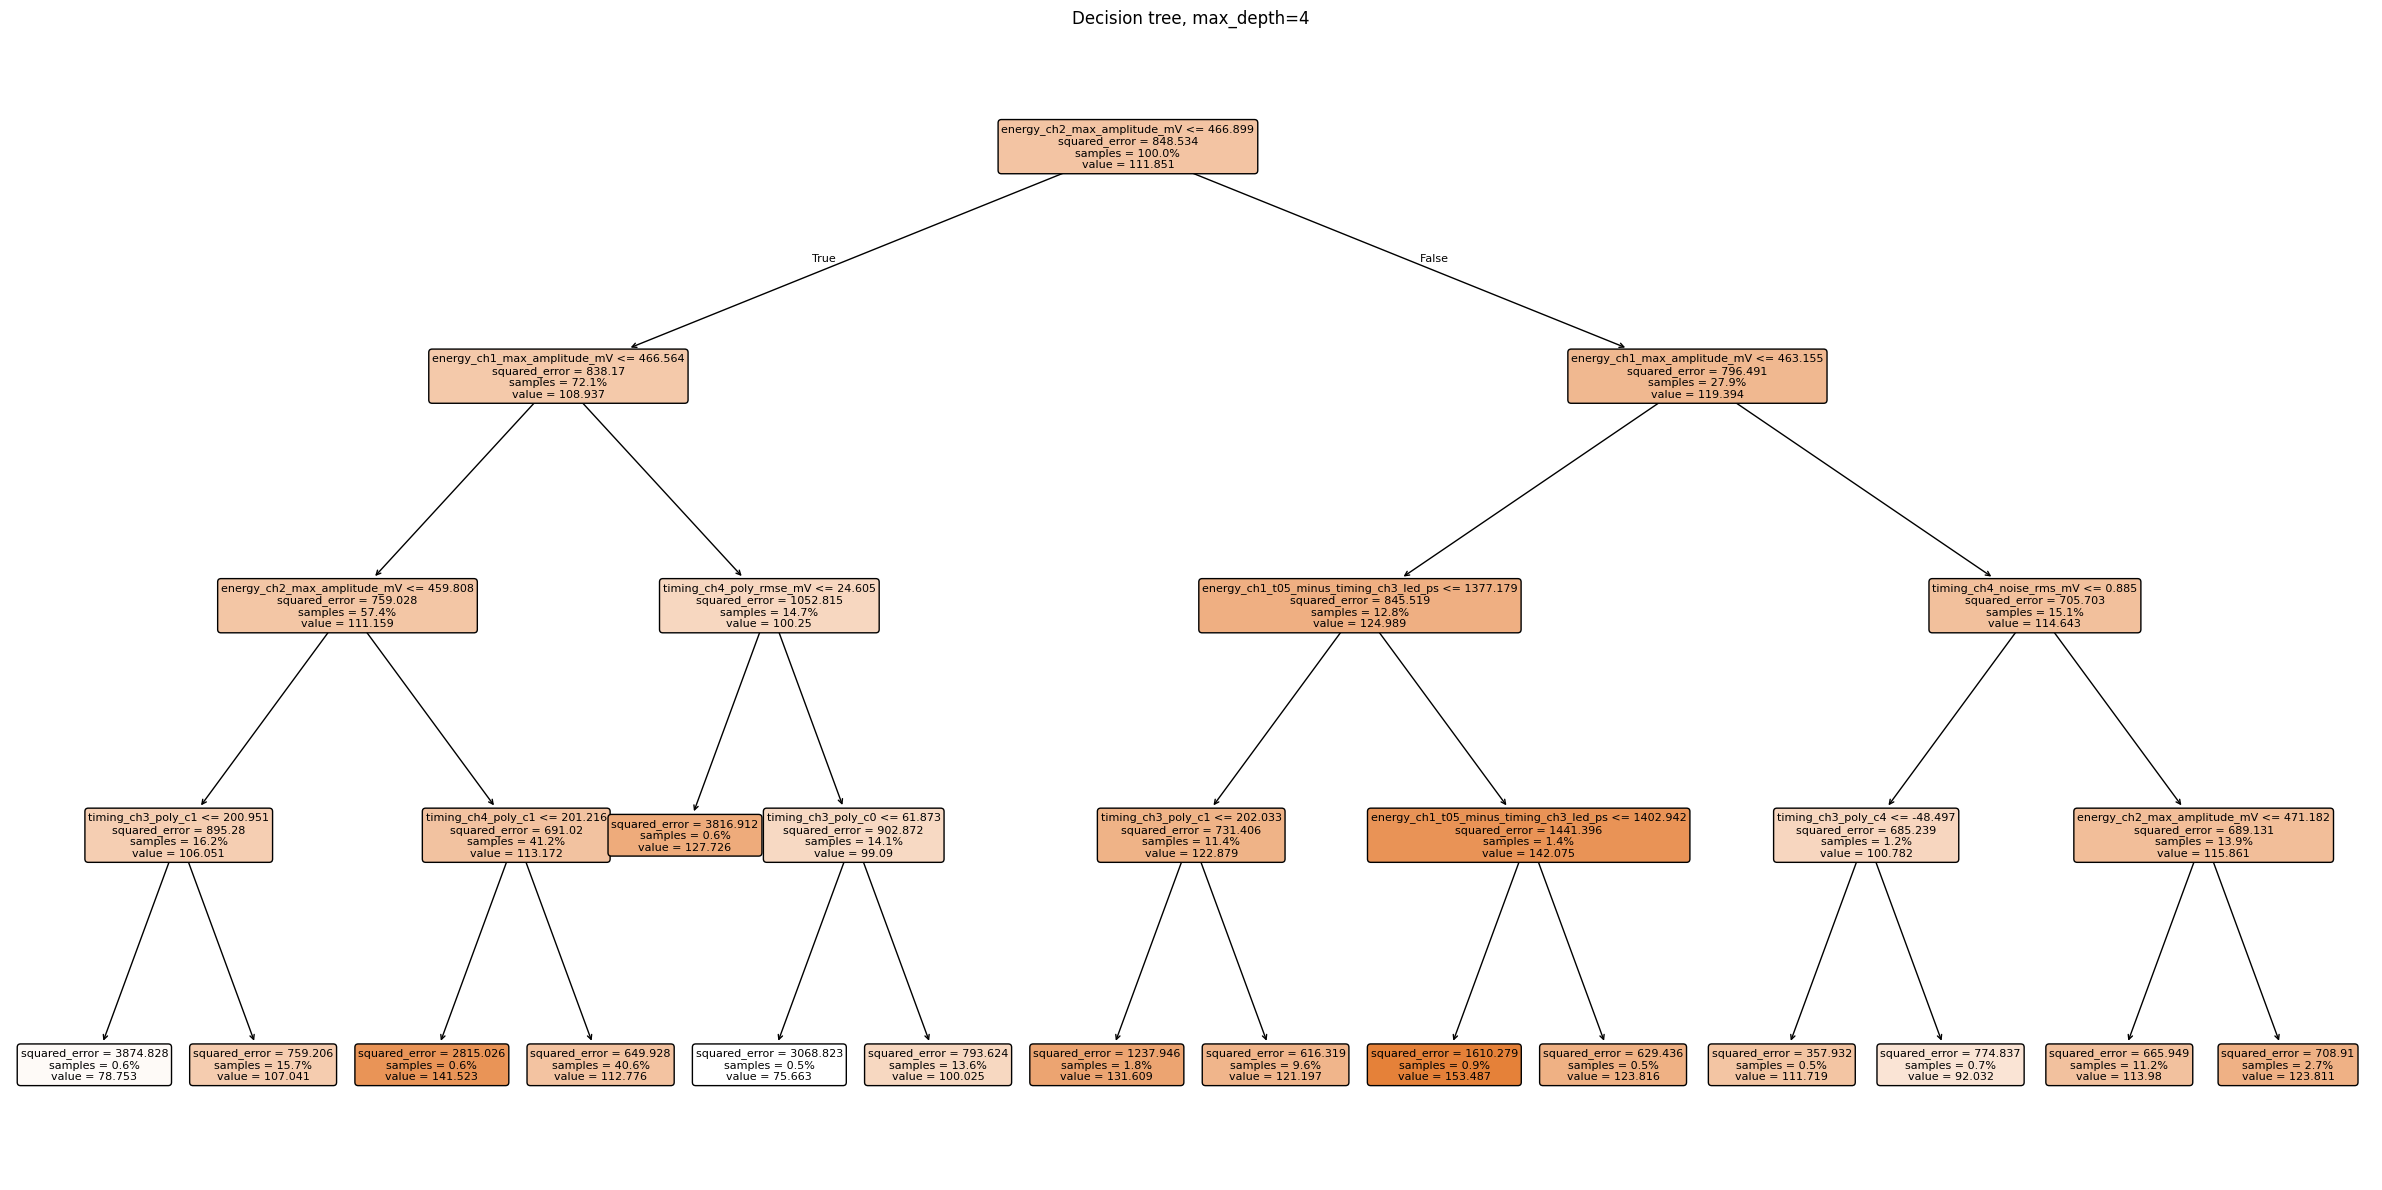

In [103]:
fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=feature_columns,
    filled=True,
    rounded=True,
    proportion=True,
    impurity=True,
    fontsize=8,
    ax=ax,
)

ax.set_title(
    f"Decision tree, max_depth={SELECTED_DEPTH}"
)

plt.tight_layout()
plt.show()

In [104]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=[
        f"PC{index + 1}"
        for index in range(pca.n_components_)
    ],
)

display(loadings_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
energy_ch1_max_amplitude_mV,0.005144,-0.044887,0.187872,0.185497,-0.240402,-0.329493,-0.088198,0.081790,0.288010,0.077161,...,-0.006381,-0.001546,-0.001852,0.002093,-0.000264,-0.000241,0.000438,0.000167,0.000000e+00,-0.000000e+00
energy_ch1_noise_rms_mV,0.004848,0.007165,-0.040970,-0.024663,0.094774,-0.003613,0.083291,0.223013,-0.200237,0.910127,...,0.000691,0.005401,0.000797,0.000062,-0.000167,-0.000087,-0.000171,-0.000078,-7.239715e-17,4.746838e-16
energy_ch1_rise_t05_to_t50_ps,0.006538,-0.234377,0.651951,-0.033449,0.021700,0.049942,0.021183,-0.019548,-0.033028,0.012018,...,-0.001017,-0.000700,0.000455,-0.001705,-0.000256,-0.000189,0.000029,0.000143,3.161574e-02,7.042244e-01
energy_ch1_t05_minus_timing_ch3_led_ps,-0.197493,0.024594,-0.041457,-0.215873,0.206899,0.115647,-0.049181,0.016861,-0.079815,-0.065587,...,0.010263,0.000937,-0.001992,-0.004735,0.000476,-0.000136,-0.000291,-0.001240,3.931090e-03,8.756300e-02
energy_ch1_t50_minus_timing_ch3_led_ps,-0.018046,-0.231680,0.647805,-0.060385,0.047500,0.064422,0.015091,-0.017478,-0.043019,0.003869,...,0.000259,-0.000584,0.000207,-0.002297,-0.000197,-0.000207,-0.000007,-0.000011,-3.156653e-02,-7.031282e-01


In [105]:
def top_loadings(
    loadings: pd.DataFrame,
    component: str,
    top_n: int = 15,
) -> pd.DataFrame:
    result = pd.DataFrame(
        {
            "feature": loadings.index,
            "loading": loadings[component].to_numpy(),
        }
    )

    result["absolute_loading"] = result["loading"].abs()

    return (
        result
        .sort_values("absolute_loading", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


for component in ["PC1", "PC2", "PC3"]:
    print(component)
    display(
        top_loadings(
            loadings_df,
            component,
            top_n=TOP_N_FEATURES,
        )
    )

PC1


,feature,loading,absolute_loading
0,timing_ch3_poly_c0,0.290668,0.290668
1,timing_ch4_poly_c0,0.290272,0.290272
2,timing_ch3_poly_c2,-0.290154,0.290154
3,timing_ch4_poly_c2,-0.289720,0.289720
4,timing_ch3_poly_c4,0.289020,0.289020
5,timing_ch4_poly_c4,0.288421,0.288421
6,timing_ch3_poly_c3,-0.250360,0.250360
7,timing_ch4_poly_c1,0.248449,0.248449
8,timing_ch3_poly_c1,0.247947,0.247947
9,timing_ch4_poly_c3,-0.247904,0.247904


PC2


,feature,loading,absolute_loading
0,energy_ch2_rise_t05_to_t50_ps,0.635151,0.635151
1,energy_ch2_t50_minus_timing_ch4_led_ps,0.625003,0.625003
2,energy_ch2_max_amplitude_mV,0.273582,0.273582
3,energy_ch1_rise_t05_to_t50_ps,-0.234377,0.234377
4,energy_ch1_t50_minus_timing_ch3_led_ps,-0.231680,0.231680
5,energy_ch2_t05_minus_timing_ch4_led_ps,-0.109827,0.109827
6,timing_ch4_max_amplitude_mV,-0.048190,0.048190
7,energy_ch1_max_amplitude_mV,-0.044887,0.044887
8,timing_ch4_poly_rmse_mV,0.034867,0.034867
9,timing_ch4_poly_r2,-0.034593,0.034593


PC3


,feature,loading,absolute_loading
0,energy_ch1_rise_t05_to_t50_ps,0.651951,0.651951
1,energy_ch1_t50_minus_timing_ch3_led_ps,0.647805,0.647805
2,energy_ch2_rise_t05_to_t50_ps,0.224040,0.224040
3,energy_ch2_t50_minus_timing_ch4_led_ps,0.219639,0.219639
4,energy_ch1_max_amplitude_mV,0.187872,0.187872
5,energy_ch2_max_amplitude_mV,0.108631,0.108631
6,energy_ch2_t05_minus_timing_ch4_led_ps,-0.044730,0.044730
7,energy_ch1_t05_minus_timing_ch3_led_ps,-0.041457,0.041457
8,energy_ch1_noise_rms_mV,-0.040970,0.040970
9,timing_ch4_noise_rms_mV,0.040817,0.040817


In [107]:
components_for_90 = int(
    np.argmax(
        explained_variance_df[
            "cumulative_explained_variance"
        ].to_numpy() >= 0.90
    ) + 1
)

components_for_95 = int(
    np.argmax(
        explained_variance_df[
            "cumulative_explained_variance"
        ].to_numpy() >= 0.95
    ) + 1
)

print(f"Components required for 90% variance: {components_for_90}")
print(f"Components required for 95% variance: {components_for_95}")

Components required for 90% variance: 13
Components required for 95% variance: 15


In [108]:
N_PCA_IMPORTANCE_COMPONENTS = components_for_90

selected_components = pca.components_[
    :N_PCA_IMPORTANCE_COMPONENTS
]

selected_variance = pca.explained_variance_ratio_[
    :N_PCA_IMPORTANCE_COMPONENTS
]

pca_variance_importance = np.sum(
    selected_components**2
    * selected_variance[:, np.newaxis],
    axis=0,
)

pca_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "pca_variance_importance": (
                pca_variance_importance
            ),
        }
    )
    .sort_values(
        "pca_variance_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(pca_importance_df.head(TOP_N_FEATURES))

,feature,pca_variance_importance
0,energy_ch1_t50_minus_timing_ch3_led_ps,0.035675
1,energy_ch1_noise_rms_mV,0.035659
2,timing_ch3_noise_rms_mV,0.035612
3,energy_ch1_rise_t05_to_t50_ps,0.035594
4,timing_ch4_noise_rms_mV,0.035274
5,energy_ch2_noise_rms_mV,0.035182
6,energy_ch2_rise_t05_to_t50_ps,0.035164
7,timing_ch3_max_amplitude_mV,0.035047
8,energy_ch2_t50_minus_timing_ch4_led_ps,0.034870
9,timing_ch3_poly_r2,0.034865


In [109]:
combined_importance_df = (
    impurity_importance_df
    .merge(
        permutation_importance_df,
        on="feature",
        how="outer",
    )
    .merge(
        pca_importance_df,
        on="feature",
        how="outer",
    )
)

combined_importance_df = combined_importance_df.sort_values(
    "importance_mean_ps",
    ascending=False,
)

display(
    combined_importance_df.head(TOP_N_FEATURES)
)

,feature,importance,importance_mean_ps,importance_std_ps,pca_variance_importance
0,energy_ch1_max_amplitude_mV,0.263333,0.697411,0.136027,0.033743
5,energy_ch2_max_amplitude_mV,0.369806,0.401223,0.294935,0.019833
12,timing_ch3_poly_c0,0.038123,0.227876,0.060092,0.032159
1,energy_ch1_noise_rms_mV,0.000000,0.000000,0.000000,0.035659
26,timing_ch4_poly_r2,0.000000,0.000000,0.000000,0.034400
25,timing_ch4_poly_c4,0.000000,0.000000,0.000000,0.033838
24,timing_ch4_poly_c3,0.000000,0.000000,0.000000,0.031351
23,timing_ch4_poly_c2,0.000000,0.000000,0.000000,0.033230
21,timing_ch4_poly_c0,0.000000,0.000000,0.000000,0.032069
19,timing_ch4_max_amplitude_mV,0.000000,0.000000,0.000000,0.025171


In [116]:
from pathlib import Path

repository_root = Path.cwd()

discrete_files = list(
    repository_root.rglob("tof_discrete.csv")
)

continuous_files = list(
    repository_root.rglob("tof_continuous.csv")
)

print("Discrete datasets:")
for path in discrete_files:
    print(path.resolve())

print("\nContinuous datasets:")
for path in continuous_files:
    print(path.resolve())

Discrete datasets:
C:\Users\aless\Desktop\UChicago\2026-ONAOSI-EFI-Project-3---CTR-analysis\waveform_analysis\datasets\common_shift_experiment\tof_discrete.csv

Continuous datasets:
C:\Users\aless\Desktop\UChicago\2026-ONAOSI-EFI-Project-3---CTR-analysis\waveform_analysis\datasets\common_shift_experiment\tof_continuous.csv


In [120]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DISCRETE_PATH = Path(
    r"datasets\common_shift_experiment\tof_discrete.csv"
)

df_discrete = pd.read_csv(DISCRETE_PATH)

print(df_discrete.shape)
display(df_discrete.head())

(6733, 57)


,meta_event_index,meta_event_id,meta_source_file_id,meta_shift_mode,meta_assigned_shift_ps,meta_discrete_group,target_shift_ps,energy_ch1_max_amplitude_mV,energy_ch1_t10_abs_ps,energy_ch2_max_amplitude_mV,...,timing_ch4_c22_PD_PeriodicityWang_th0_01,timing_ch4_c22_SB_BinaryStats_diff_longstretch0,timing_ch4_c22_SB_BinaryStats_mean_longstretch1,timing_ch4_c22_SB_MotifThree_quantile_hh,timing_ch4_c22_SB_TransitionMatrix_3ac_sumdiagcov,timing_ch4_c22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,timing_ch4_c22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,timing_ch4_c22_SP_Summaries_welch_rect_area_5_1,timing_ch4_c22_SP_Summaries_welch_rect_centroid,timing_ch4_t7_abs_ps
0,3,3,3;3;3;3,discrete,0,1,0.0,249.977441,-23880.630205,194.938801,...,0.0,38.0,242.0,1.251604,0.062500,0.854167,0.125000,0.997335,0.006136,-24924.424572
1,4,4,4;4;4;4,discrete,-80,0,-80.0,242.816699,-24250.082156,223.794061,...,0.0,43.0,269.0,1.319109,0.041667,0.145833,0.145833,0.997528,0.006136,-25468.132707
2,12,12,12;12;12;12,discrete,0,1,0.0,230.620858,-24204.284908,217.736941,...,0.0,34.0,262.0,1.277136,0.041667,0.854167,0.166667,0.997491,0.006136,-25319.972970
3,14,14,14;14;14;14,discrete,80,2,80.0,249.462899,-24797.891598,220.838987,...,285.0,37.0,296.0,1.271384,0.111111,0.854167,0.208333,0.997516,0.006136,-26016.471543
4,19,19,19;19;19;19,discrete,0,1,0.0,250.983380,-24777.367606,224.864020,...,0.0,36.0,294.0,1.226459,0.074074,0.854167,0.208333,0.997524,0.006136,-25973.075886


In [122]:
import numpy as np
import pandas as pd

TARGET_COLUMN = "target_shift_ps"

timing_crossing_columns = sorted(
    column
    for column in df_discrete.columns
    if column.startswith("timing_ch")
    and column.endswith("_abs_ps")
)

if len(timing_crossing_columns) != 2:
    raise ValueError(
        "Expected two timing absolute-time columns, found: "
        f"{timing_crossing_columns}"
    )

t3_column, t4_column = timing_crossing_columns

diagnostic_df = df_discrete[
    [TARGET_COLUMN, t3_column, t4_column]
].dropna().copy()

diagnostic_df["mean_timing_crossing_ps"] = (
    diagnostic_df[t3_column]
    + diagnostic_df[t4_column]
) / 2.0

diagnostic_df["timing_difference_ps"] = (
    diagnostic_df[t3_column]
    - diagnostic_df[t4_column]
)

print(
    "Correlation shift vs mean absolute timing:",
    diagnostic_df[
        [TARGET_COLUMN, "mean_timing_crossing_ps"]
    ].corr().iloc[0, 1],
)

print(
    "Correlation shift vs timing difference:",
    diagnostic_df[
        [TARGET_COLUMN, "timing_difference_ps"]
    ].corr().iloc[0, 1],
)

Correlation shift vs mean absolute timing: 0.10129318522064407
Correlation shift vs timing difference: 0.005551877963741803


In [123]:
group_summary = (
    diagnostic_df
    .groupby(TARGET_COLUMN)
    .agg(
        events=(TARGET_COLUMN, "size"),
        mean_t3_ps=(t3_column, "mean"),
        mean_t4_ps=(t4_column, "mean"),
        mean_common_time_ps=(
            "mean_timing_crossing_ps",
            "mean",
        ),
        std_common_time_ps=(
            "mean_timing_crossing_ps",
            "std",
        ),
        mean_difference_ps=(
            "timing_difference_ps",
            "mean",
        ),
    )
    .reset_index()
)

display(group_summary)

,target_shift_ps,events,mean_t3_ps,mean_t4_ps,mean_common_time_ps,std_common_time_ps,mean_difference_ps
0,-80.0,2246,-25346.583225,-25381.073275,-25363.828250,596.754306,34.490050
1,0.0,2244,-25269.214736,-25309.437200,-25289.325968,596.003685,40.222465
2,80.0,2243,-25188.108423,-25233.625637,-25210.867030,646.335537,45.517214
